<a href="https://colab.research.google.com/github/aaditya9803/ml/blob/main/Condition%20monitoring%20of%20hydraulic%20systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Importing files from Google drive



In [1]:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import os

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# List of file names.
file_names = ['CE.txt', 'CP.txt', 'EPS1.txt', 'FS1.txt', 'FS2.txt',
              'PS1.txt', 'PS2.txt', 'PS3.txt', 'PS4.txt', 'PS5.txt',
              'PS6.txt', 'SE.txt', 'TS1.txt', 'TS2.txt', 'TS3.txt',
              'TS4.txt', 'VS1.txt','profile.txt']

# Get the ID of the current folder (where the notebook is located).
# Assuming the notebook is in "My Drive/Colab Notebooks" or similar
# by default.
# Alternatively, you can get a specific folder ID or use a method to find your folder
current_folder_id = '1KSKmvJYgR1N_0dOffHON1SFAlrlfwpMs' # Replace with your specific folder ID if needed


# Iterate through the file names and download each file.
for file_name in file_names:
    # List files in the current folder.
    file_list = drive.ListFile({'q': "'{}' in parents and trashed=false".format(current_folder_id)}).GetList()

    # Find the file with the matching name.
    file_to_download = next((file for file in file_list if file['title'] == file_name), None)

    if file_to_download:
        # Download the file.
        print(f"Downloading {file_name}...")
        file_to_download.GetContentFile(file_name)  # Downloads to Colab environment
    else:
        print(f"File {file_name} not found in the folder.")

print("All files downloaded (if found).")

All files downloaded (if found).


# Importing python libraries

In [27]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import xgboost as xgb
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pickle
from google.colab import files

## Features and Targets

In [4]:
def read_file(filename):
    return pd.read_csv((filename), sep='\t', header=None)

pressureFile1 = read_file(filename='PS1.txt')
pressureFile2 = read_file(filename='PS2.txt')
pressureFile3 = read_file(filename='PS3.txt')
pressureFile4 = read_file(filename='PS4.txt')
pressureFile5 = read_file(filename='PS5.txt')
pressureFile6 = read_file(filename='PS6.txt')


volumeFlow1 = read_file(filename='FS1.txt')
volumeFlow2 = read_file(filename='FS2.txt')


temperature1 = read_file(filename='TS1.txt')
temperature2 = read_file(filename='TS2.txt')
temperature3 = read_file(filename='TS3.txt')
temperature4 = read_file(filename='TS4.txt')

pump1 = read_file(filename='EPS1.txt')
vibration1 = read_file(filename='VS1.txt')
coolingE1 = read_file(filename='CE.txt')
coolingP1 = read_file(filename='CP.txt')
effFactor1 = read_file(filename='SE.txt')

profile = read_file(filename='profile.txt')


# for the targets

y_coolerCondition = pd.DataFrame(profile.iloc[:, 0])
y_valveCondition = pd.DataFrame(profile.iloc[:, 1])
y_pumpLeak = pd.DataFrame(profile.iloc[:, 2])
y_hydraulicAcc = pd.DataFrame(profile.iloc[:, 3])
y_stableFlag = pd.DataFrame(profile.iloc[:, 4])


In [5]:
pressureFile1.shape


(2205, 6000)

##Functions to Upsample and Downsample

In [6]:
#converts 100hz to 10hz
def mean_conversion_100hz(df, chunk_size=10, prefix=''):
    num_chunks = df.shape[1] // chunk_size
    columns = [f'{prefix}_{i}' for i in range(num_chunks)]
    df_mean_chunks = pd.DataFrame(index=df.index, columns=columns)

    for index, row in df.iterrows():
        mean_chunks = row.values.reshape(-1, chunk_size).mean(axis=1)
        df_mean_chunks.loc[index] = mean_chunks

    return df_mean_chunks


#converts 100hz to 1z
def mean_conversion_1hz(df, chunk_size=100, prefix=''):
    num_chunks = df.shape[1] // chunk_size
    columns = [f'{prefix}_{i}' for i in range(num_chunks)]
    df_mean_chunks = pd.DataFrame(index=df.index, columns=columns)

    for index, row in df.iterrows():
        mean_chunks = row.values.reshape(-1, chunk_size).mean(axis=1)
        df_mean_chunks.loc[index] = mean_chunks

    return df_mean_chunks

#For Upsampling
def repeat_values(df, repeat_count=10):
    all_expanded_rows = []

    for index, row in df.iterrows():
        expanded_row = np.repeat(row.values, repeat_count)
        all_expanded_rows.append(pd.Series(expanded_row))
    df_expanded = pd.concat(all_expanded_rows, ignore_index=True)  # Concatenate all rows at once

    return df_expanded

#For mean of the row (mean of the cycle)
def mean_conversion(df):
    df1 = pd.DataFrame()
    df1['mean'] = df.mean(axis=1)
    return df1

## Upsampling and Downsampling to 10hz

In [7]:
# #100HZ TO 10HZ
# PS1 = mean_conversion_100hz(pressureFile1)
# PS1.columns = [f'PS1_{i}' for i in range(PS1.shape[1])]

# PS2 = mean_conversion_100hz(pressureFile2)
# PS2.columns = [f'PS2_{i}' for i in range(PS2.shape[1])]

# PS3 = mean_conversion_100hz(pressureFile3)
# PS3.columns = [f'PS3_{i}' for i in range(PS3.shape[1])]

# PS4 = mean_conversion_100hz(pressureFile4)
# PS4.columns = [f'PS4_{i}' for i in range(PS4.shape[1])]

# PS5 = mean_conversion_100hz(pressureFile5)
# PS5.columns = [f'PS5_{i}' for i in range(PS5.shape[1])]

# PS6 = mean_conversion_100hz(pressureFile6)
# PS6.columns = [f'PS6_{i}' for i in range(PS6.shape[1])]

# P1 = mean_conversion_100hz(pump1)
# P1.columns = [f'P1_{i}' for i in range(P1.shape[1])]

# #Leaving 10HZ as it is

# FS1 = pd.DataFrame(volumeFlow1)
# FS1.columns = [f'FS1_{i}' for i in range(FS1.shape[1])]

# FS2 = pd.DataFrame(volumeFlow2)
# FS2.columns = [f'FS2_{i}' for i in range(FS2.shape[1])]

# #1HZ to 10HZ

# TS1 = pd.DataFrame(repeat_values(temperature1))
# TS1.columns = ['TS1']

# TS2 = pd.DataFrame(repeat_values(temperature2))
# TS2.columns = ['TS2']

# TS3 = pd.DataFrame(repeat_values(temperature3))
# TS3.columns = ['TS3']

# TS4 = pd.DataFrame(repeat_values(temperature4))
# TS4.columns = ['TS4']

# VS1 = pd.DataFrame(repeat_values(vibration1))
# VS1.columns = ['VS1']

# CE1 = pd.DataFrame(repeat_values(coolingE1))
# CE1.columns = ['CE1']

# CP1 = pd.DataFrame(repeat_values(coolingP1))
# CP1.columns = ['CP1']

# SE1 = pd.DataFrame(repeat_values(effFactor1))
# SE1.columns = ['SE1']

## DownSampling to 1HZ

In [8]:
#100HZ TO 1HZ
PS1 = mean_conversion_1hz(pressureFile1)
PS1.columns = [f'PS1_{i}' for i in range(PS1.shape[1])]

PS2 = mean_conversion_1hz(pressureFile2)
PS2.columns = [f'PS2_{i}' for i in range(PS2.shape[1])]

PS3 = mean_conversion_1hz(pressureFile3)
PS3.columns = [f'PS3_{i}' for i in range(PS3.shape[1])]

PS4 = mean_conversion_1hz(pressureFile4)
PS4.columns = [f'PS4_{i}' for i in range(PS4.shape[1])]

PS5 = mean_conversion_1hz(pressureFile5)
PS5.columns = [f'PS5_{i}' for i in range(PS5.shape[1])]

PS6 = mean_conversion_1hz(pressureFile6)
PS6.columns = [f'PS6_{i}' for i in range(PS6.shape[1])]

P1 = mean_conversion_1hz(pump1)
P1.columns = [f'P1_{i}' for i in range(P1.shape[1])]

#10hz to 1hz

FS1 = pd.DataFrame(mean_conversion_100hz(volumeFlow1))
FS1.columns = [f'FS1_{i}' for i in range(FS1.shape[1])]

FS2 = pd.DataFrame(mean_conversion_100hz(volumeFlow2))
FS2.columns = [f'FS2_{i}' for i in range(FS2.shape[1])]

#Leaving 1HZ as it is

TS1 = pd.DataFrame(temperature1)
TS1.columns = [f'TS1_{i}' for i in range(TS1.shape[1])]

TS2 = pd.DataFrame(temperature2)
TS2.columns = [f'TS2_{i}' for i in range(TS2.shape[1])]

TS3 = pd.DataFrame(temperature3)
TS3.columns = [f'TS3_{i}' for i in range(TS3.shape[1])]

TS4 = pd.DataFrame(temperature4)
TS4.columns = [f'TS4_{i}' for i in range(TS4.shape[1])]

VS1 = pd.DataFrame(vibration1)
VS1.columns = [f'VS1_{i}' for i in range(VS1.shape[1])]

CE1 = pd.DataFrame(coolingE1)
CE1.columns = [f'CE1_{i}' for i in range(CE1.shape[1])]

CP1 = pd.DataFrame(coolingP1)
CP1.columns = [f'CP1_{i}' for i in range(CP1.shape[1])]

SE1 = pd.DataFrame(effFactor1)
SE1.columns = [f'SE1_{i}' for i in range(SE1.shape[1])]

## Mean of a cycle (of the whole row)

In [9]:
# PS1 = pd.DataFrame(mean_conversion(pressureFile1))
# PS1.columns = ['PS1'] # Rename the column to 'PS1'

# PS2 = pd.DataFrame(mean_conversion(pressureFile2))
# PS2.columns = ['PS2']

# PS3 = pd.DataFrame(mean_conversion(pressureFile3))
# PS3.columns = ['PS3']

# PS4 = pd.DataFrame(mean_conversion(pressureFile4))
# PS4.columns = ['PS4']

# PS5 = pd.DataFrame(mean_conversion(pressureFile5))
# PS5.columns = ['PS5']

# PS6 = pd.DataFrame(mean_conversion(pressureFile6))
# PS6.columns = ['PS6']

# FS1 = pd.DataFrame(mean_conversion(volumeFlow1))
# FS1.columns = ['FS1']

# FS2 = pd.DataFrame(mean_conversion(volumeFlow2))
# FS2.columns = ['FS2']

# TS1 = pd.DataFrame(mean_conversion(temperature1))
# TS1.columns = ['TS1']

# TS2 = pd.DataFrame(mean_conversion(temperature2))
# TS2.columns = ['TS2']

# TS3 = pd.DataFrame(mean_conversion(temperature3))
# TS3.columns = ['TS3']

# TS4 = pd.DataFrame(mean_conversion(temperature4))
# TS4.columns = ['TS4']

# P1 = pd.DataFrame(mean_conversion(pump1))
# P1.columns = ['P1']

# VS1 = pd.DataFrame(mean_conversion(vibration1))
# VS1.columns = ['VS1']

# CE1 = pd.DataFrame(mean_conversion(coolingE1))
# CE1.columns = ['CE1']

# CP1 = pd.DataFrame(mean_conversion(coolingP1))
# CP1.columns = ['CP1']

# SE1 = pd.DataFrame(mean_conversion(effFactor1))
# SE1.columns = ['SE1']

In [31]:
PS1.shape

(2205, 60)

In [32]:
X = pd.concat([PS1, PS2, PS3, PS4, PS5, PS6, FS1, FS2, TS1, TS2, TS3, TS4, P1, VS1, CE1, CP1, SE1], axis=1)
#X1.hist(bins=50, figsize=(20, 15))

In [33]:
for col in X.select_dtypes(include=['object']).columns:
    try:
        X[col] = pd.to_numeric(X[col])
    except ValueError:
        print(f"Could not convert column {col} to numeric. It might contain non-numeric values.")

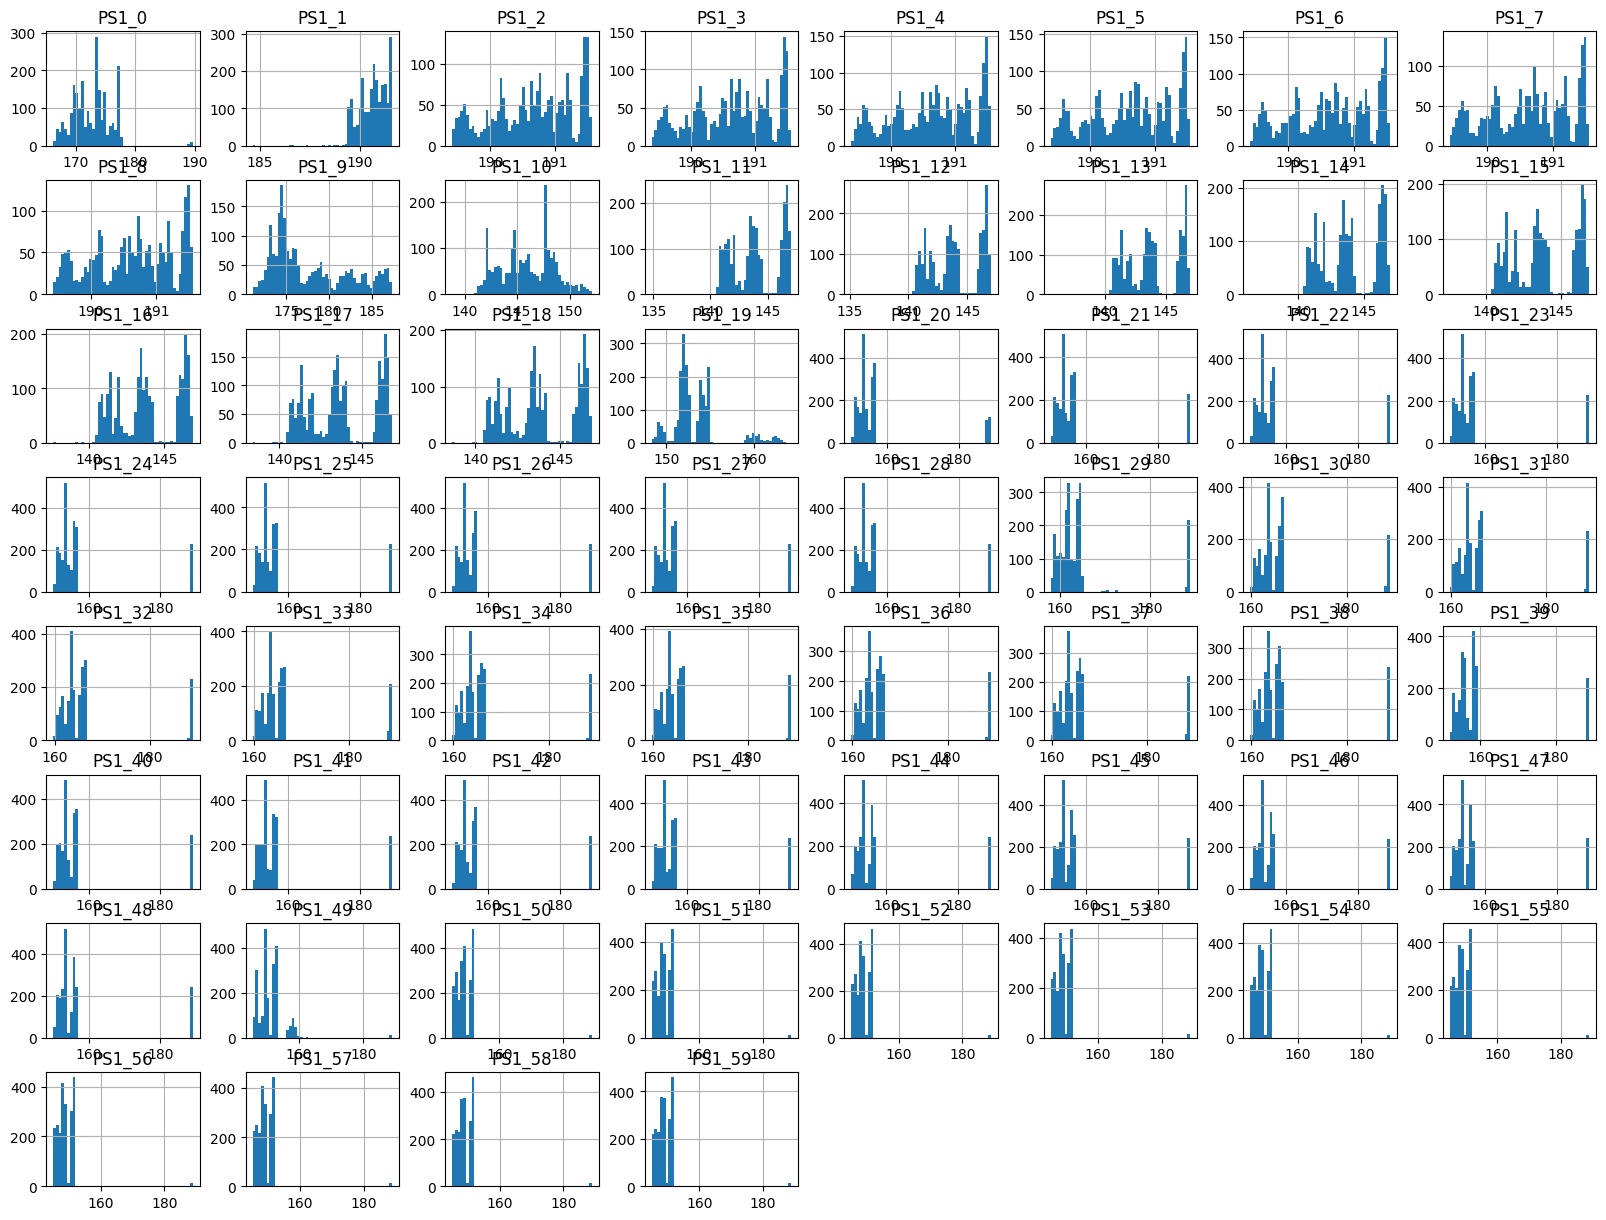

In [34]:
# Convert applicable columns to numeric type before plotting.
for col in PS1.columns:  # Changed PS3 to PS1
    try:
        # Attempt to convert the column to numeric.
        PS1[col] = pd.to_numeric(PS1[col])  # Changed PS3 to PS1
    except ValueError:
        # If conversion fails (e.g., due to non-numeric values),
        # print a message and continue.
        print(f"Could not convert column {col} to numeric. It might contain non-numeric values.")

# Now you can try plotting the histogram again.
PS1.hist(bins=50, figsize=(20, 15))
plt.show()

## Using XGB

In [35]:
def predict_pump_performance(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

    X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.2, random_state=24)

    num_classes = len(np.unique(y_train))

    if num_classes < 2:
        raise ValueError("Target variable must have at least 2 unique values for multi-class classification.")

    seed= 24

    if num_classes == 2 and len(y.shape) == 1:
        objective_func = 'binary:logistic'
    else:
        objective_func = 'multi:softprob'

    xgb1 = xgb.sklearn.XGBClassifier(
            learning_rate =0.1,
             n_estimators=100,
             max_depth=5,
             min_child_weight=11,
             gamma=0.1,
             subsample=0.8,
             colsample_bytree=0.7,
             objective=objective_func,
             n_jobs=-1,
             scale_pos_weight=1,
             seed=seed,
             num_class=num_classes
    )

    xgb1.fit(X_train, y_train)

    if objective_func == 'multi:softprob':
        y_pred_probs = xgb1.predict_proba(X_val)
        y_pred = np.argmax(y_pred_probs, axis=1)
    else:
        y_pred = xgb1.predict(X_val)

    y_val = y_val.astype(int)
    y_pred = y_pred.astype(int)

    #confusion matrix and classification report

    cm = confusion_matrix(y_val, y_pred)

    print(classification_report(y_val, y_pred))

    with open('XGB_model.pkl', 'wb') as f:
        pickle.dump(xgb1, f)

    files.download('XGB_model.pkl')

In [36]:
predict_pump_performance(X, y_stableFlag)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [07:23:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.95      0.98      0.97        58
           1       0.97      0.90      0.93        31

    accuracy                           0.96        89
   macro avg       0.96      0.94      0.95        89
weighted avg       0.96      0.96      0.95        89



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Using Linear Regression

In [37]:
def predict_pump_performance_linear(X, y, num_folds=5):
    kf = KFold(n_splits=num_folds, shuffle = True, random_state=24)
    mse_scores = []
    r2_scores = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mse_scores.append(mse)
        r2_scores.append(r2)

        print(f"Mean Squared Error: {np.mean(mse_scores):.4f}")
        print(f"R-squared: {r2}")

    with open('linear_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    files.download('linear_model.pkl')

In [38]:
predict_pump_performance_linear(X, y_stableFlag)

Mean Squared Error: 0.0931
R-squared: 0.5541383527835676
Mean Squared Error: 0.0975
R-squared: 0.5634644874213119
Mean Squared Error: 0.0914
R-squared: 0.6571962744874664
Mean Squared Error: 0.1090
R-squared: 0.3055421444858971
Mean Squared Error: 0.1034
R-squared: 0.6246756146032382


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Using SVM

In [39]:
def svm(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

    # Feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create the SVM model
    model = SVC(kernel='rbf',
    C=1, gamma='auto')

    # Perform cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5)  # 5-fold cross-validation

    # Print cross-validation scores
    print("Cross-validation scores:", scores)
    print("Average cross-validation score:", scores.mean())


    # Train the model on the entire training set
    model.fit(X_train, y_train)

    # Make predictions on the test set and evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test set accuracy: {accuracy}")

    # Save the model
    with open('svm_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    files.download('svm_model.pkl')

In [40]:
svm(X,y_stableFlag)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

Cross-validation scores: [0.90614887 0.90614887 0.92556634 0.92857143 0.93181818]
Average cross-validation score: 0.9196507376119026


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test set accuracy: 0.9244712990936556


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Using Random forest

In [42]:
def randomforest(X, y, num_folds=5):
    kf = KFold(n_splits=num_folds, shuffle = True, random_state=24)
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)
        y_pred = rf_model.predict(X_test)
        print(classification_report(y_test, y_pred))
        print(f"Fold {fold_idx + 1}")

    with open('RandomForest_model.pkl', 'wb') as f:
        pickle.dump(rf_model, f)

    files.download('RandomForest_model.pkl')

In [43]:
randomforest(X,y_stableFlag)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.97      1.00      0.98       310
           1       1.00      0.92      0.96       131

    accuracy                           0.98       441
   macro avg       0.98      0.96      0.97       441
weighted avg       0.98      0.98      0.97       441

Fold 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       277
           1       1.00      0.93      0.96       164

    accuracy                           0.97       441
   macro avg       0.98      0.96      0.97       441
weighted avg       0.97      0.97      0.97       441

Fold 2


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


...

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       278
           1       1.00      0.95      0.97       163

    accuracy                           0.98       441
   macro avg       0.99      0.98      0.98       441
weighted avg       0.98      0.98      0.98       441

Fold 4


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       303
           1       1.00      0.91      0.95       138

    accuracy                           0.97       441
   macro avg       0.98      0.96      0.97       441
weighted avg       0.97      0.97      0.97       441

Fold 5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Using Neural Networks

In [46]:
def neuralnetwork(X, y, num_folds=10, patience=3):
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=24)
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Build the model
        model = keras.Sequential([
            keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # EarlyStopping callback
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True # Changed Truetask2 to True
        )

        # Fit the model with early stopping callback
        model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping]
        )

        # Evaluate the model on the test set after training
        test_loss, test_accuracy = model.evaluate(X_test, y_test)
        print(f"Fold {fold_idx + 1}: Test Loss = {test_loss:.4f}, Test Accuracy = {test_accuracy:.4f}")

    with open('nn_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    files.download('nn_model.pkl')


In [47]:
neuralnetwork(X,y_stableFlag)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7619 - loss: 0.4558 - val_accuracy: 0.7783 - val_loss: 0.4714
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9325 - loss: 0.1711 - val_accuracy: 0.6650 - val_loss: 1.0664
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9433 - loss: 0.1404 - val_accuracy: 0.8086 - val_loss: 0.4879
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9527 - loss: 0.1349 - val_accuracy: 0.7632 - val_loss: 0.6843
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9326 - loss: 0.2344 
Fold 1: Test Loss = 0.2220, Test Accuracy = 0.9276
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8094 - loss: 0.4274 - val_accuracy: 0.6776 - val_loss: 0.7266
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9393 - loss: 0.1795 - val_accuracy: 0.7935 - val_loss: 0.4771
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9444 - loss: 0.1442 - val_accuracy: 0.8237 - val_loss: 0.4580
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9355 - loss: 0.1489 - val_accuracy: 0.5239 - val_loss: 2.0418
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9473 - loss: 0.1351 - val_accuracy: 0.7254 - val_loss: 0.7543
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9710 - loss: 0.0958 - val_accuracy: 0.7783 - val_loss: 0.6114
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9107 - loss: 0.1889 
Fold 2: Test Loss = 0.2113, Test Accuracy = 0.8914
Epoch 1/100


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8164 - loss: 0.4738 - val_accuracy: 0.7229 - val_loss: 0.5276
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9383 - loss: 0.1801 - val_accuracy: 0.7431 - val_loss: 0.5615
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9386 - loss: 0.1487 - val_accuracy: 0.7632 - val_loss: 0.5974
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9509 - loss: 0.1442 - val_accuracy: 0.7708 - val_loss: 0.5410
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9170 - loss: 0.2196 
Fold 9: Test Loss = 0.2724, Test Accuracy = 0.9000
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7807 - loss: 0.4243 - val_accuracy: 0.7380 - val_loss: 0.5727
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9248 - loss: 0.1962 - val_accuracy: 0.5869 - val_loss: 1.5735
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9417 - loss: 0.1555 - val_accuracy: 0.6071 - val_loss: 1.4368
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9527 - loss: 0.1414 - val_accuracy: 0.6474 - val_loss: 1.5071
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9217 - loss: 0.3256 
Fold 10: Test Loss = 0.3974, Test Accuracy = 0.8500


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>